In [1]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    # model="bistable",
    # params={"a": 0.5, "k": 100},
)
# solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("BackwardEuler"))
# solver = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

dt = 1 / Nx * 0.5 * 8
tEnd = 10

u = np.array([np.sin(fv.xcs * np.pi * 2)]) * 1 + 0

# u1 = solver.stepInterval(dt, u, 0.0, tEnd)

solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp(0.5))

u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
    use_exp=True,
)

iter [[0.5, 1],10], resN [7.8418e-02 / 1.9393e+01]
iter [[0.5, 1],16], resN [9.2037e-04 / 1.9393e+01]
Step [1], t = [3.1250e-02] uNorm [7.999984958527526]
iter [[0.5, 1],10], resN [7.8418e-02 / 1.9393e+01]
iter [[0.5, 1],16], resN [9.2036e-04 / 1.9393e+01]
Step [2], t = [6.2500e-02] uNorm [7.999969958426334]
iter [[0.5, 1],10], resN [7.8418e-02 / 1.9393e+01]
iter [[0.5, 1],16], resN [9.2035e-04 / 1.9393e+01]
Step [3], t = [9.3750e-02] uNorm [7.999954979863504]
iter [[0.5, 1],10], resN [7.8418e-02 / 1.9392e+01]
iter [[0.5, 1],16], resN [9.2035e-04 / 1.9392e+01]
Step [4], t = [1.2500e-01] uNorm [7.999940010758837]
iter [[0.5, 1],10], resN [7.8419e-02 / 1.9392e+01]
iter [[0.5, 1],16], resN [9.2035e-04 / 1.9392e+01]
Step [5], t = [1.5625e-01] uNorm [7.999925048354803]
iter [[0.5, 1],10], resN [7.8419e-02 / 1.9392e+01]
iter [[0.5, 1],16], resN [9.2035e-04 / 1.9392e+01]
Step [6], t = [1.8750e-01] uNorm [7.999910091484139]
iter [[0.5, 1],10], resN [7.8419e-02 / 1.9392e+01]
iter [[0.5, 1],16],

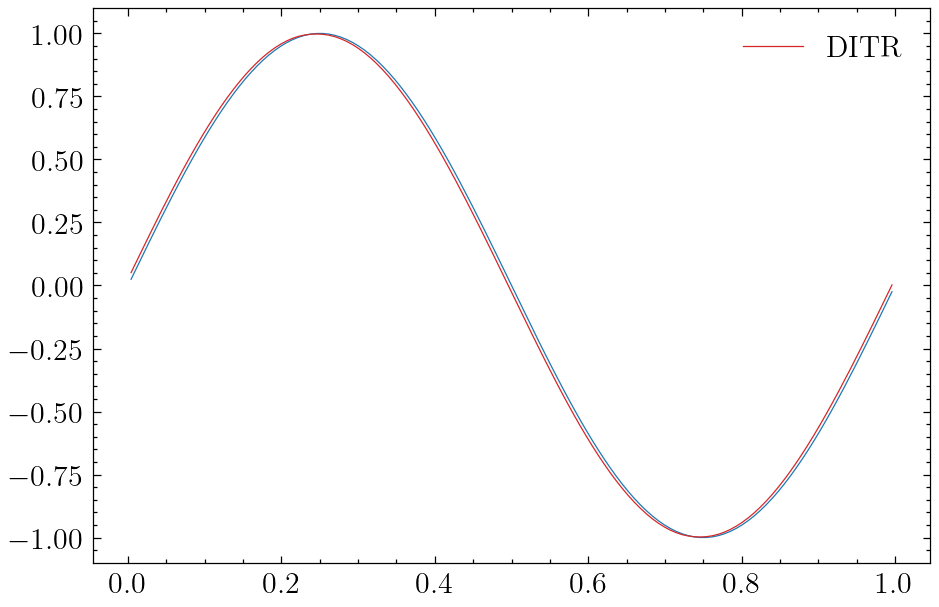

In [2]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=0)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u[0], plotIndex=0)
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plt.legend()
plt.show()